### GT数据和predict得到的SWD对比__得到__TP,FP,FN
image:

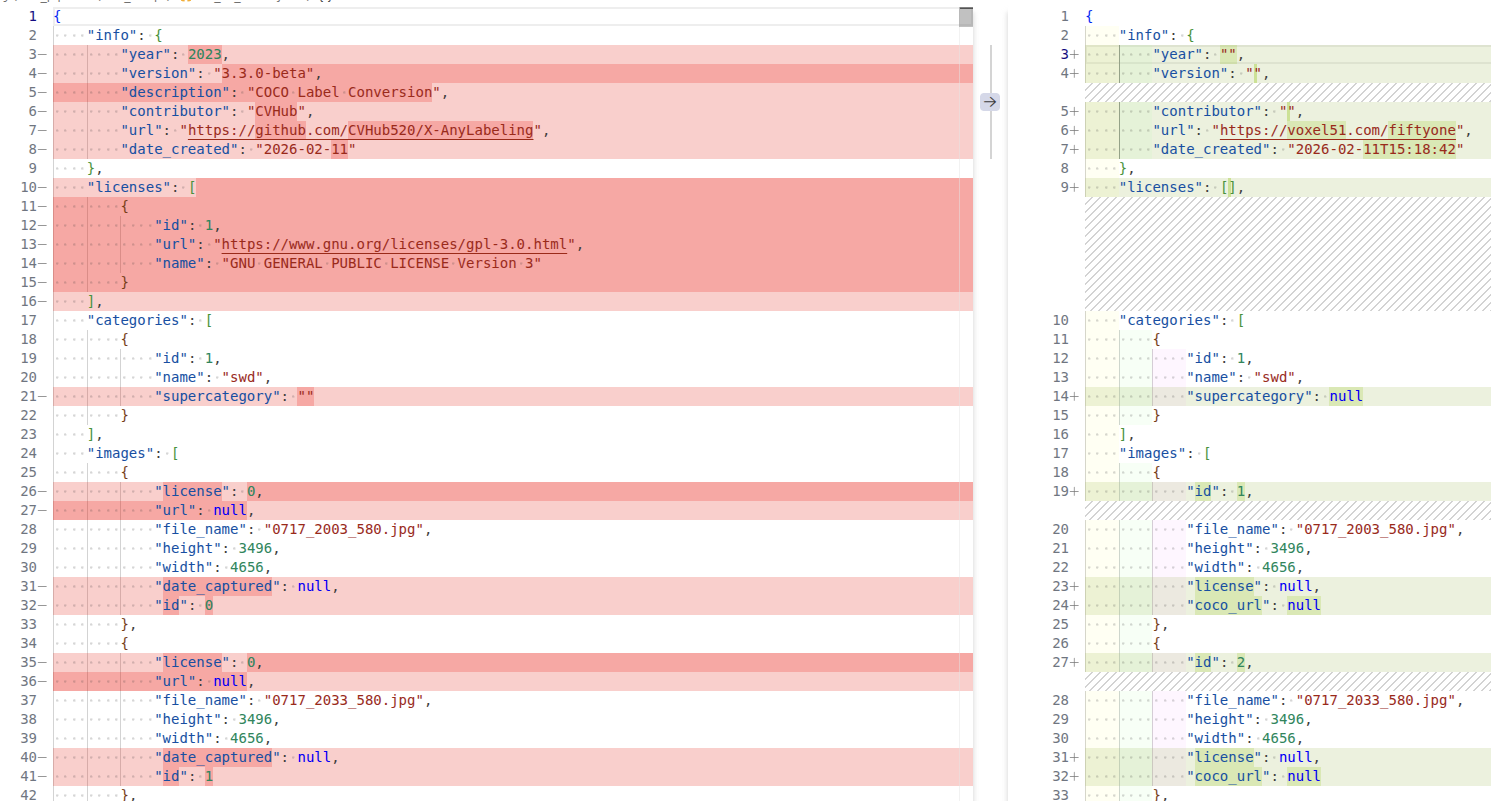

annotation:

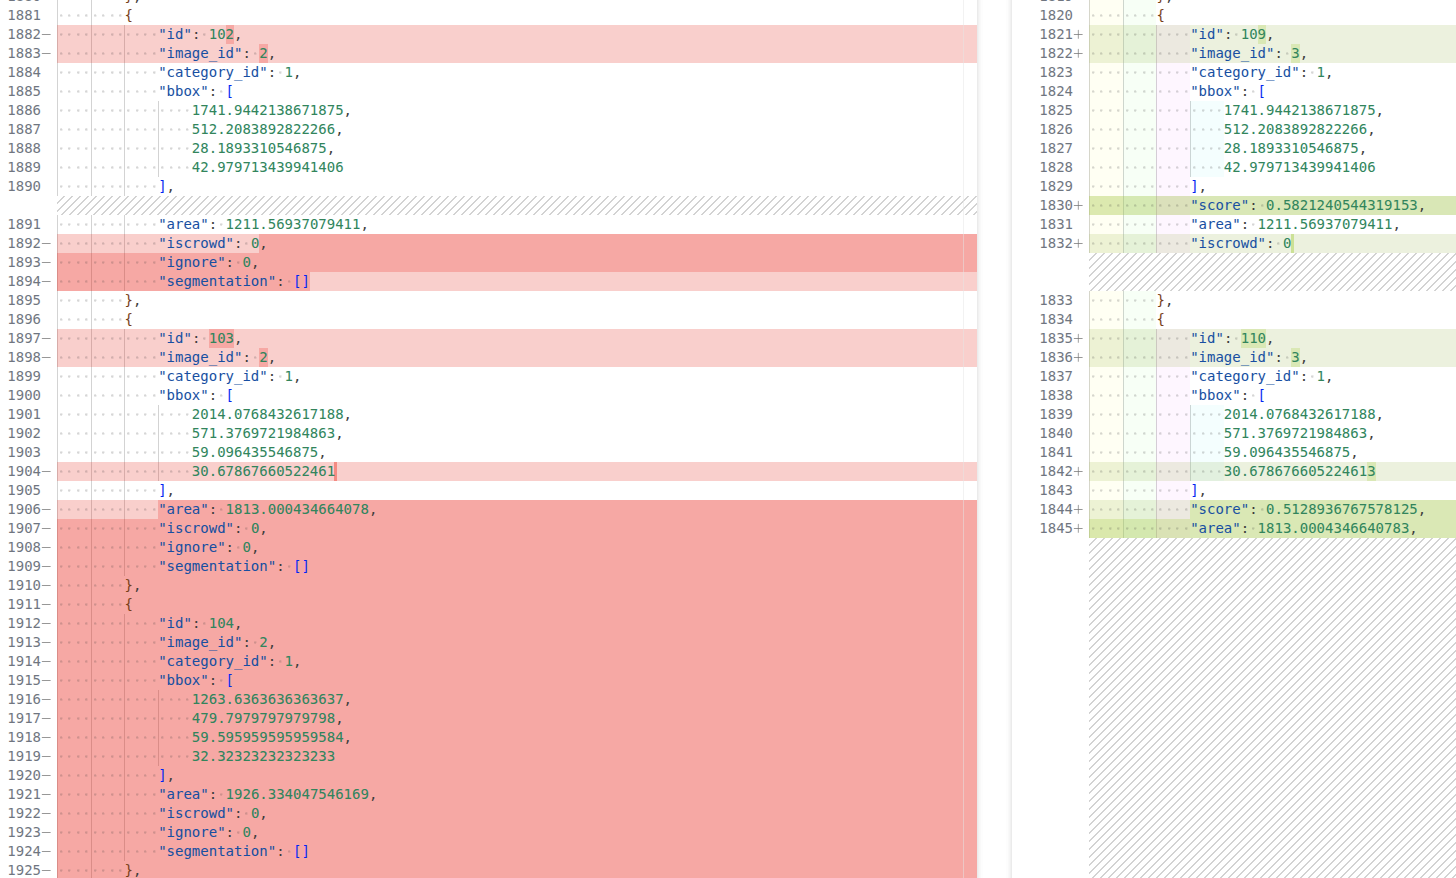

In [13]:
import json
import pandas as pd


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


# IoU for COCO bbox [x, y, w, h]
def iou_coco(b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2

    xa = max(x1, x2)
    ya = max(y1, y2)
    xb = min(x1 + w1, x2 + w2)
    yb = min(y1 + h1, y2 + h2)

    inter = max(0.0, xb - xa) * max(0.0, yb - ya)
    area1 = max(0.0, w1) * max(0.0, h1)
    area2 = max(0.0, w2) * max(0.0, h2)

    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union


def build_id2name(coco):
    return {img["id"]: img["file_name"] for img in coco.get("images", [])}


def annotations_to_filename_df(coco, id2name):
    ann = coco.get("annotations", [])
    if not ann:
        return pd.DataFrame(columns=["file_name", "bbox", "score"])

    df = pd.DataFrame(ann)

    # bbox 必须有
    df = df[["image_id", "bbox"] + ([ "score" ] if "score" in df.columns else [])].copy()

    if "score" not in df.columns:
        df["score"] = float("nan")

    df["file_name"] = df["image_id"].map(id2name)

    df = df.dropna(subset=["file_name"])

    return df[["file_name", "bbox", "score"]]


def per_image_eval_by_filename(gt_path, pred_path, iou_thr=0.9, score_thr=None):

    gt = load_json(gt_path)
    pred = load_json(pred_path)

    gt_id2name = build_id2name(gt)
    pred_id2name = build_id2name(pred)

    gt_df = annotations_to_filename_df(gt, gt_id2name)
    pred_df = annotations_to_filename_df(pred, pred_id2name)

    # ⭐ score filtering (ONLY for pred)
    if score_thr is not None and "score" in pred_df.columns:
        pred_df = pred_df[pred_df["score"] >= score_thr]

    gt_group = gt_df.groupby("file_name")["bbox"].apply(list).to_dict()
    pred_group = pred_df.groupby("file_name")["bbox"].apply(list).to_dict()

    all_files = sorted(
        set(gt_id2name.values())
        | set(pred_id2name.values())
        | set(gt_group.keys())
        | set(pred_group.keys())
    )

    rows = []

    for fn in all_files:
        gt_boxes = gt_group.get(fn, [])
        pred_boxes = pred_group.get(fn, [])

        matched_gt = set()
        tp = 0
        fp = 0

        for pb in pred_boxes:
            best_iou = 0.0
            best_idx = -1

            for gi, gb in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue

                iou = iou_coco(pb, gb)

                if iou > best_iou:
                    best_iou = iou
                    best_idx = gi

            if best_iou >= iou_thr and best_idx != -1:
                tp += 1
                matched_gt.add(best_idx)
            else:
                fp += 1

        fn_count = len(gt_boxes) - len(matched_gt)

        gt_count = len(gt_boxes)
        pred_count = len(pred_boxes)

        precision = tp / pred_count if pred_count else 0.0
        recall = tp / gt_count if gt_count else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

        rows.append({
            "file_name": fn,
            "gt_count": gt_count,
            "pred_count": pred_count,
            "tp (Hit)": tp,
            "fp (Error Warning)": fp,
            "fn (Miss)": fn_count,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    out_df = pd.DataFrame(rows).sort_values("file_name")
    return out_df


# =========================
# RUN
# =========================
gt_path = "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/00_temp/annotations/coco_detection.json"

pred_path = "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/00_temp/01_all_labels_nocls.json"
# pred_path = "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/00_temp/01_all_labels.json"

score_thr = 0.5   # ⭐ 这里改

df = per_image_eval_by_filename(
    gt_path,
    pred_path,
    iou_thr=0.9,
    score_thr=score_thr,   # ⭐ 这里改
)

averages = df[['gt_count', 'pred_count', 'tp (Hit)', 'fp (Error Warning)', 'fn (Miss)', 'precision', 'recall', 'f1']].mean()
averages['file_name'] = 'Average'  # Add a label for the row
df = pd.concat([df, pd.DataFrame([averages])], ignore_index=True)

out_csv = f"/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/00_temp/per_image_eval_iou90_score_{score_thr}_by_filename.csv"


df.to_csv(out_csv, index=False)

print("Saved →", out_csv)
df

Saved → /home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/00_temp/per_image_eval_iou90_score_0.5_by_filename.csv


,file_name,gt_count,pred_count,tp (Hit),fp (Error Warning),fn (Miss),precision,recall,f1
0,0717_2003_580.jpg,0.000000,3.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
1,0717_2033_580.jpg,1.000000,4.0,1.000000,3.000000,0.000000,0.250000,1.000000,0.400000
2,0718_0604_580.jpg,113.000000,103.0,103.000000,0.000000,10.000000,1.000000,0.911504,0.953704
3,0718_0634_580.jpg,89.000000,81.0,80.000000,1.000000,9.000000,0.987654,0.898876,0.941176
4,0718_0704_580.jpg,82.000000,70.0,70.000000,0.000000,12.000000,1.000000,0.853659,0.921053
5,0718_0734_580.jpg,69.000000,59.0,56.000000,3.000000,13.000000,0.949153,0.811594,0.875000
6,0718_0804_580.jpg,60.000000,43.0,42.000000,1.000000,18.000000,0.976744,0.700000,0.815534
7,0718_0834_580.jpg,65.000000,47.0,47.000000,0.000000,18.000000,1.000000,0.723077,0.839286
8,0718_0904_580.jpg,54.000000,45.0,45.000000,0.000000,9.000000,1.000000,0.833333,0.909091
9,0718_0934_580.jpg,56.000000,48.0,48.000000,0.000000,8.000000,1.000000,0.857143,0.923077
